# 02 · EDA — Mediterranean Basin Scale (scalable to global)

This notebook is designed to work at any scale larger than Turkey such as Mediterranean basin, global, or anything in between. It does not rely on per-ecoregion visual inspection. Instead it uses:

1. **Scalar flags** computed per ecoregion and stored in the master CSV
2. **Summary visualisations** that show the full distribution across all ecoregions at once
3. **Targeted inspection** only for ecoregions that trigger multiple flags

**Outputs:** `outputs/<scale>/graphs/`

**Scale:** Designed for Med basin (~80–100 ecoregions) but produces identical outputs at global scale (~800 ecoregions) without modification.

In [19]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import glob
import json
import os
from scipy import stats
from scipy.signal import find_peaks
from shapely.geometry import shape

# ── CONFIG — change scale here, nothing else needs to change ──────────────────
SCALE      = 'med_basin'          # used in output filenames — change to 'global' etc.
OUTPUT_DIR = 'outputs/med_basin'
DAILY_DIR  = f'{OUTPUT_DIR}/daily_counts'

SMOOTH_WIN      = 7
MIN_VALID_YEARS = 20
MIN_ANNUAL_DET  = 50     # ecoregion-years below this are flagged as sparse
MIN_ECO_DET     = 500    # ecoregions with mean annual detections below this are flagged
HIGH_CV_THRESH  = 40     # onset CV above this (%) flagged as high variability
BC_THRESH       = 0.555  # bimodality coefficient threshold

graphs_dir = f'{OUTPUT_DIR}/graphs'
os.makedirs(graphs_dir, exist_ok=True)

print(f'Scale: {SCALE}')
print(f'Output: {OUTPUT_DIR}')

Scale: med_basin
Output: outputs/med_basin


In [20]:
# ── LOAD MASTER CSV AND FILTER ────────────────────────────────────────────────
master_df = pd.read_csv(f'{OUTPUT_DIR}/master_{SCALE}.csv')

valid_year_counts = master_df.groupby('eco_name')['year'].count().rename('n_valid_years')
passing  = valid_year_counts[valid_year_counts >= MIN_VALID_YEARS].index
excluded = valid_year_counts[valid_year_counts <  MIN_VALID_YEARS]

if len(excluded) > 0:
    print(f'Excluded {len(excluded)} ecoregion(s) with < {MIN_VALID_YEARS} valid years:')
    for name, n in excluded.items():
        print(f'  {name}: {n} valid years')

master_df = master_df[master_df['eco_name'].isin(passing)].copy()
ecoregions = sorted(master_df['eco_name'].unique())
n_eco = len(ecoregions)

print(f'\nRetained: {n_eco} ecoregions, {len(master_df)} rows')
print(f'Years: {master_df["year"].min()} – {master_df["year"].max()}')

Excluded 3 ecoregion(s) with < 20 valid years:
  Appenine deciduous montane forests: 14 valid years
  Corsican montane broadleaf and mixed forests: 15 valid years
  Saharan halophytics: 16 valid years

Retained: 55 ecoregions, 1256 rows
Years: 2003 – 2025


In [6]:
# ── LOAD DAILY DATA ───────────────────────────────────────────────────────────
daily_files = sorted(glob.glob(f'{DAILY_DIR}/*_daily.csv'))
if not daily_files:
    raise FileNotFoundError(f'No daily CSVs in {DAILY_DIR}')

all_daily = pd.concat([pd.read_csv(f) for f in daily_files], ignore_index=True)
all_daily = all_daily[all_daily['eco_name'].isin(ecoregions)].copy()
all_daily = all_daily.sort_values(['eco_name', 'year', 'doy']).reset_index(drop=True)

print(f'Loaded {len(daily_files)} daily CSVs')

Loaded 59 daily CSVs


---
## Section 1: Ecoregion-Level Flag Computation

Scalar quality flags computed once per ecoregion and stored as a CSV.
These travel with your data at any scale — add columns, never remove them.

Flags do not exclude anything automatically. They are diagnostic metadata
used to stratify, colour-code, and filter downstream analyses.

In [7]:
# ── COMPUTE ECOREGION-LEVEL FLAGS ─────────────────────────────────────────────
# One row per ecoregion. All scalar summary statistics and boolean flags.

def bimodality_coefficient(series):
    """Sarle's bimodality coefficient. BC > 0.555 suggests bimodality.
    BC = (skewness^2 + 1) / kurtosis
    Uses excess kurtosis + 3 to get raw kurtosis as denominator."""
    n    = len(series)
    if n < 4:
        return np.nan
    skew = stats.skew(series)
    kurt = stats.kurtosis(series) + 3   # convert excess kurtosis to raw kurtosis
    if kurt == 0:
        return np.nan
    return (skew**2 + 1) / kurt

def profile_flatness(smooth_profile):
    """Ratio of mean to peak of smoothed annual profile.
    High = flat season. Low = sharp concentrated peak."""
    peak = smooth_profile.max()
    if peak == 0:
        return np.nan
    return smooth_profile.mean() / peak

rows = []
for eco in ecoregions:
    # ── Detection-based stats ────────────────────────────────────────────────
    sub_daily = all_daily[all_daily['eco_name'] == eco]
    annual    = sub_daily.groupby('year')['n_detections'].sum()

    total_det        = annual.sum()
    mean_annual_det  = annual.mean()
    n_valid          = valid_year_counts.get(eco, 0)
    pct_below_thresh = (annual < MIN_ANNUAL_DET).mean() * 100

    # ── CV of metrics ────────────────────────────────────────────────────────
    sub_master = master_df[master_df['eco_name'] == eco]
    def cv(col):
        m = sub_master[col].mean()
        return (sub_master[col].std() / m * 100) if m != 0 else np.nan

    onset_cv  = cv('onset_doy')
    peak_cv   = cv('peak_doy')
    end_cv    = cv('end_doy')
    sl_cv     = cv('season_length')

    # ── Implausible metric rates ──────────────────────────────────────────────
    pct_implausible_sl = (
        ((sub_master['season_length'] > 300) | (sub_master['season_length'] < 20))
        .mean() * 100
    )

    # ── Profile shape stats ───────────────────────────────────────────────────
    pivot = sub_daily.pivot_table(index='doy', columns='year',
                                   values='n_detections', aggfunc='sum')
    pivot = pivot.reindex(range(1, 366)).fillna(0)
    mean_profile = pivot.mean(axis=1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean()

    bc       = bimodality_coefficient(mean_profile.values)
    flatness = profile_flatness(mean_profile)

    # ── Boolean flags ─────────────────────────────────────────────────────────
    flag_sparse       = mean_annual_det < MIN_ECO_DET
    flag_bimodal      = bc > BC_THRESH if not np.isnan(bc) else False
    flag_high_cv      = onset_cv > HIGH_CV_THRESH if not np.isnan(onset_cv) else False
    flag_implausible  = pct_implausible_sl > 10   # >10% of years have implausible season length

    rows.append({
        'eco_name':             eco,
        'n_valid_years':        n_valid,
        'total_detections':     total_det,
        'mean_annual_det':      mean_annual_det,
        'pct_years_below_min':  pct_below_thresh,
        'onset_cv':             onset_cv,
        'peak_cv':              peak_cv,
        'end_cv':               end_cv,
        'season_length_cv':     sl_cv,
        'bimodality_coeff':     bc,
        'profile_flatness':     flatness,
        'pct_implausible_sl':   pct_implausible_sl,
        'flag_sparse':          flag_sparse,
        'flag_bimodal':         flag_bimodal,
        'flag_high_cv':         flag_high_cv,
        'flag_implausible':     flag_implausible,
    })

flags_df = pd.DataFrame(rows)
flags_df['n_flags'] = flags_df[['flag_sparse','flag_bimodal',
                                 'flag_high_cv','flag_implausible']].sum(axis=1)

flags_df.to_csv(f'{OUTPUT_DIR}/ecoregion_flags_{SCALE}.csv', index=False)
print(f'Flags computed for {len(flags_df)} ecoregions')
print(f'Sparse:      {flags_df["flag_sparse"].sum()}')
print(f'Bimodal:     {flags_df["flag_bimodal"].sum()}')
print(f'High CV:     {flags_df["flag_high_cv"].sum()}')
print(f'Implausible: {flags_df["flag_implausible"].sum()}')
print(f'2+ flags:    {(flags_df["n_flags"] >= 2).sum()}')

Flags computed for 55 ecoregions
Sparse:      11
Bimodal:     46
High CV:     29
Implausible: 18
2+ flags:    33


---
## Section 2: Quality Dashboard

Summary visualisations that replace per-ecoregion inspection at scale.
Each plot shows the full distribution across all ecoregions simultaneously.

### Graph 01: Flag Summary Heatmap

**Logic:** One row per ecoregion, one column per flag. Green = no flag, red = flagged.
Ecoregions sorted by total number of flags. The rightmost column (`n_flags`) is the
primary triage tool — ecoregions with 2+ flags warrant manual inspection.

**What to look for:**
- Ecoregions with all four flags triggered = likely exclude entirely
- Sparse + high CV together = metrics are noise-driven
- Bimodal alone = metrics technically correct but ecologically ambiguous
- How many ecoregions have zero flags = your clean analysis set

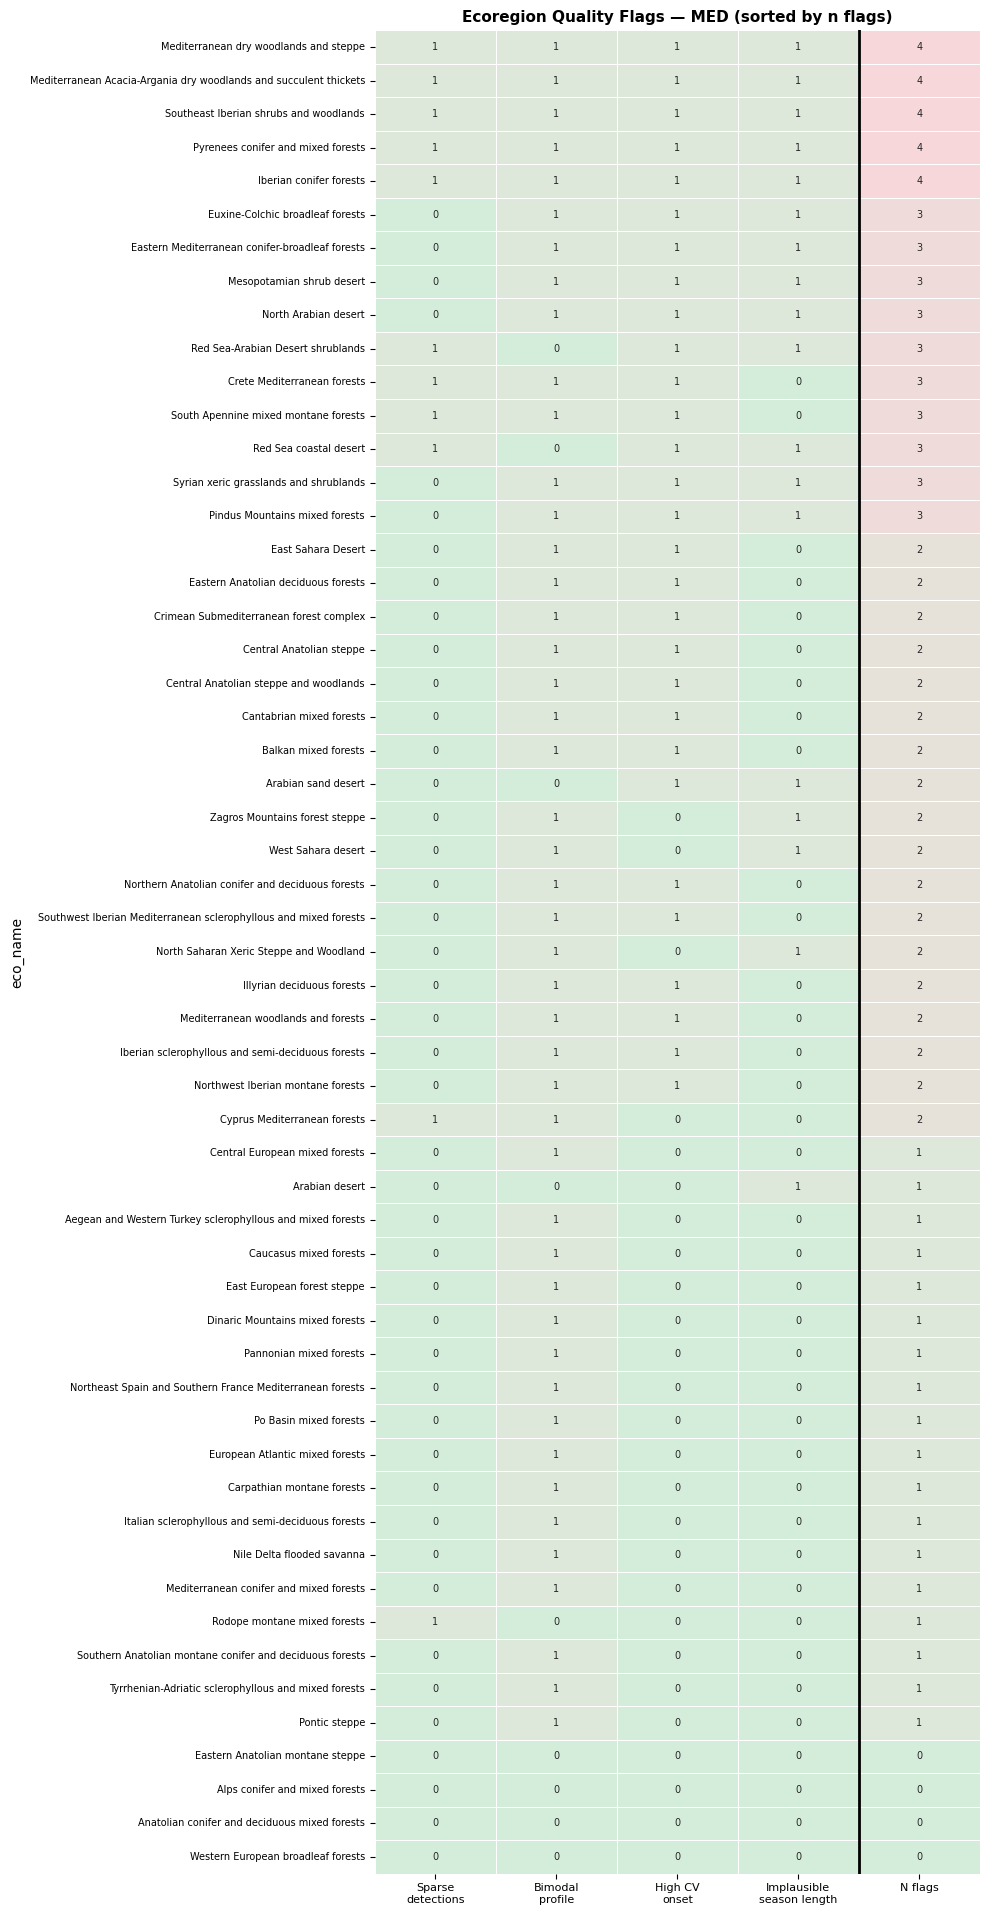

In [8]:
# ── GRAPH 01: Flag Summary Heatmap ────────────────────────────────────────────
flag_cols = ['flag_sparse', 'flag_bimodal', 'flag_high_cv', 'flag_implausible', 'n_flags']
flag_labels = ['Sparse\ndetections', 'Bimodal\nprofile', 'High CV\nonset', 
                'Implausible\nseason length', 'N flags']

plot_df = flags_df.sort_values('n_flags', ascending=False).set_index('eco_name')
flag_matrix = plot_df[flag_cols].astype(float)

fig_h = max(8, len(flags_df) * 0.35)
fig, ax = plt.subplots(figsize=(10, fig_h))

# Custom colormap: 0=green, 1=red for boolean flags; sequential for n_flags
bool_cmap = mcolors.LinearSegmentedColormap.from_list('flag', ['#d4edda', '#f8d7da'])

sns.heatmap(
    flag_matrix,
    ax         = ax,
    cmap       = bool_cmap,
    vmin       = 0, vmax = max(4, flag_matrix['n_flags'].max()),
    linewidths = 0.5,
    linecolor  = 'white',
    annot      = True,
    fmt        = '.0f',
    annot_kws  = {'size': 7},
    cbar       = False
)

ax.set_xticklabels(flag_labels, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7, rotation=0)
ax.set_title(f'Ecoregion Quality Flags — {SCALE.upper()} (sorted by n flags)',
             fontsize=11, fontweight='bold')

# Add a vertical separator before n_flags column
ax.axvline(len(flag_cols) - 1, color='black', linewidth=2)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_01_flag_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 02: Detection Count Distribution

**Logic:** Histogram of mean annual detections across all ecoregions on a log scale.
This is how you set the MIN_ECO_DET threshold — look at where the natural break in
the distribution falls, not based on an arbitrary number chosen on Turkey alone.

**What to look for:**
- Natural gaps or breaks in the distribution suggesting two populations (data-rich vs sparse)
- How many ecoregions fall below the current threshold line
- Whether the distribution is unimodal or has a long sparse tail

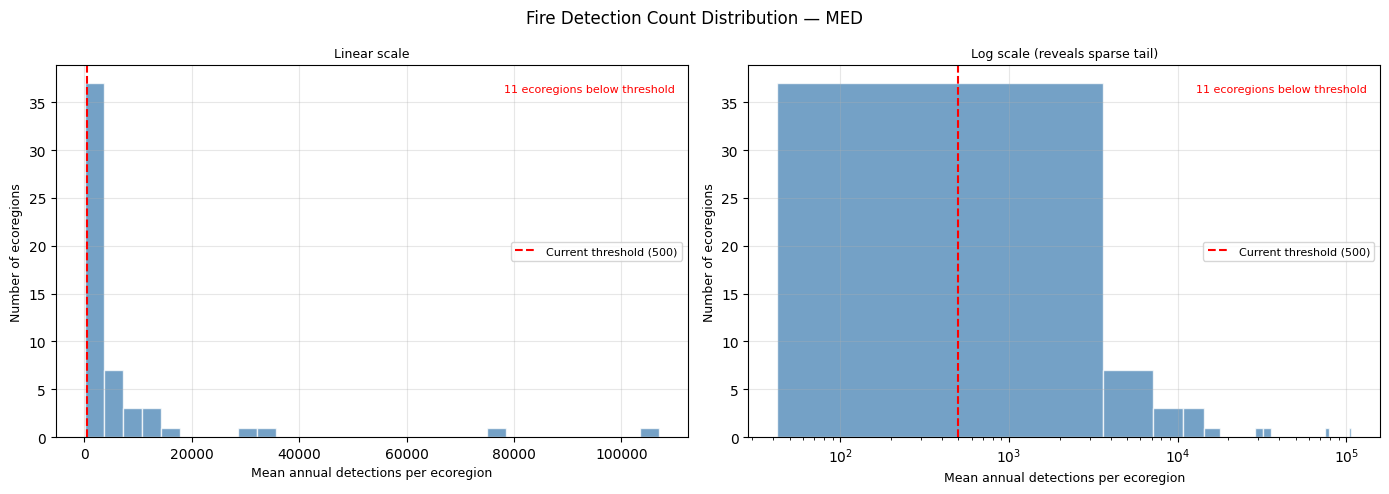

In [9]:
# ── GRAPH 02: Detection Count Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Fire Detection Count Distribution — {SCALE.upper()}', fontsize=12)

for ax, xscale, title in zip(axes, ['linear', 'log'],
                              ['Linear scale', 'Log scale (reveals sparse tail)']):
    ax.hist(flags_df['mean_annual_det'], bins=30, color='steelblue',
            alpha=0.75, edgecolor='white')
    ax.axvline(MIN_ECO_DET, color='red', linewidth=1.5, linestyle='--',
               label=f'Current threshold ({MIN_ECO_DET})')
    ax.set_xscale(xscale)
    ax.set_xlabel('Mean annual detections per ecoregion', fontsize=9)
    ax.set_ylabel('Number of ecoregions', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    n_below = (flags_df['mean_annual_det'] < MIN_ECO_DET).sum()
    ax.text(0.98, 0.95, f'{n_below} ecoregions below threshold',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='red')

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_02_detection_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 03: CV Distribution per Metric

**Logic:** Four histograms showing the distribution of CV across ecoregions for each
metric. Shows whether high variability is concentrated in onset (expected) or
spread across all metrics (unexpected — suggests data quality issues).

**What to look for:**
- Onset CV should have the widest distribution — it is the most variable metric
- Peak CV should be tightest — centroid is robust
- Ecoregions in the far right tail of onset CV are candidates for flagging
- If end CV is wider than peak CV that is expected; if it rivals onset CV that is a red flag

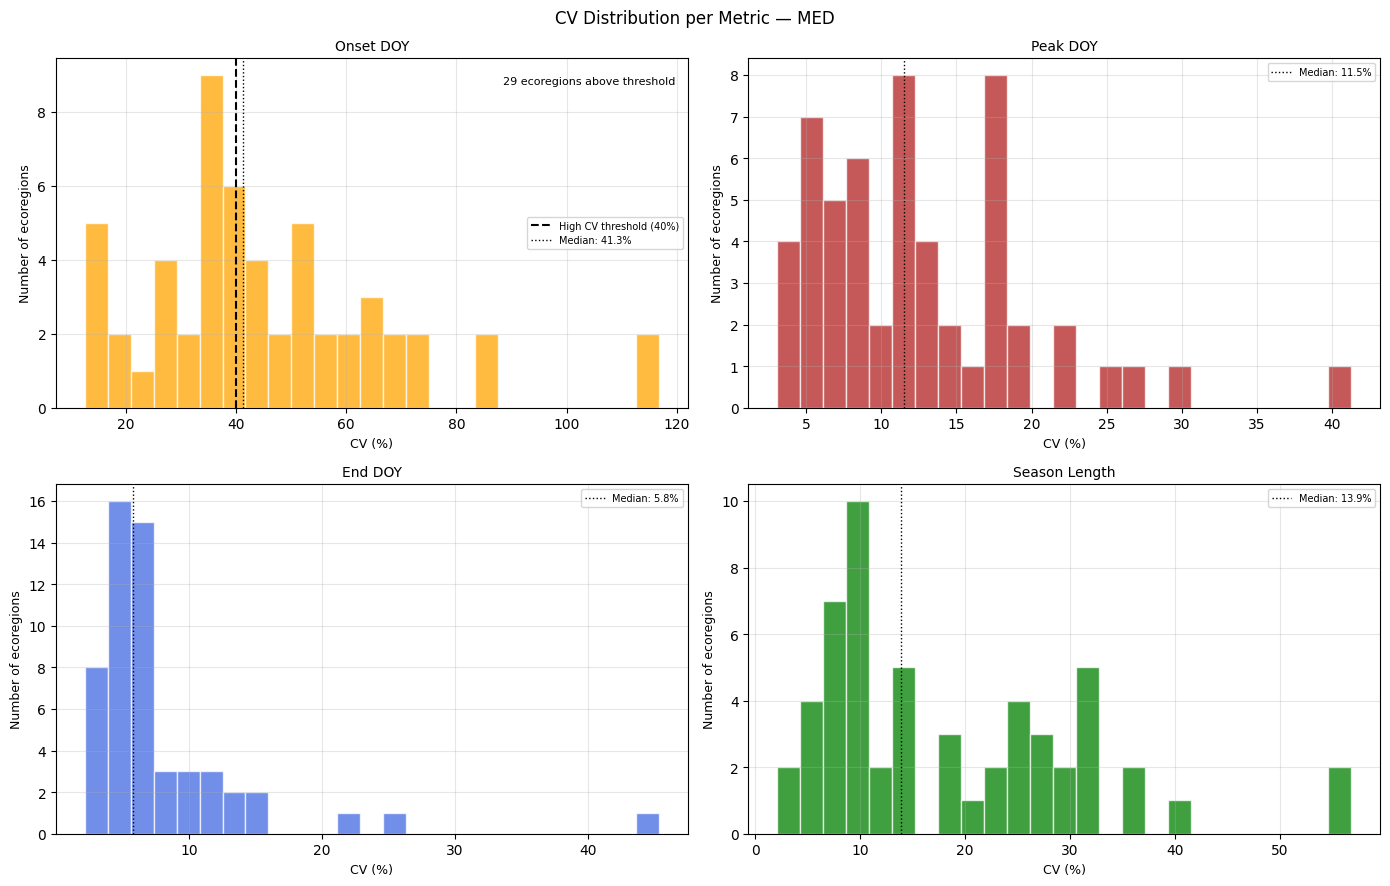

In [10]:
# ── GRAPH 03: CV Distribution per Metric ─────────────────────────────────────
cv_metrics = ['onset_cv', 'peak_cv', 'end_cv', 'season_length_cv']
cv_labels  = ['Onset DOY', 'Peak DOY', 'End DOY', 'Season Length']
cv_colors  = ['orange', 'firebrick', 'royalblue', 'green']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'CV Distribution per Metric — {SCALE.upper()}', fontsize=12)

for ax, col, label, color in zip(axes.flatten(), cv_metrics, cv_labels, cv_colors):
    data = flags_df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.75, edgecolor='white')

    if col == 'onset_cv':
        ax.axvline(HIGH_CV_THRESH, color='black', linewidth=1.5, linestyle='--',
                   label=f'High CV threshold ({HIGH_CV_THRESH}%)')
        n_high = (data > HIGH_CV_THRESH).sum()
        ax.text(0.98, 0.95, f'{n_high} ecoregions above threshold',
                transform=ax.transAxes, ha='right', va='top', fontsize=8)
        ax.legend(fontsize=7)

    ax.axvline(data.median(), color='black', linewidth=1, linestyle=':',
               label=f'Median: {data.median():.1f}%')
    ax.set_xlabel('CV (%)', fontsize=9)
    ax.set_ylabel('Number of ecoregions', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_03_cv_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 04: Bimodality Coefficient Map

**Logic:** Map of bimodality coefficient per ecoregion. Spatially shows where bimodal
fire regimes concentrate. At Med scale expect to find some bimodality in semi-arid
transition zones where spring agricultural burning and summer wildfires coexist.
At global scale expect strong signal in African savannas and Australian ecoregions.

**What to look for:**
- Spatial clustering of high BC values — bimodality is usually ecologically coherent
- Whether flagged ecoregions (BC > 0.555) form a spatially sensible pattern
- Isolated high-BC ecoregions surrounded by low-BC neighbours may be artefacts

NotImplementedError: Derived must override

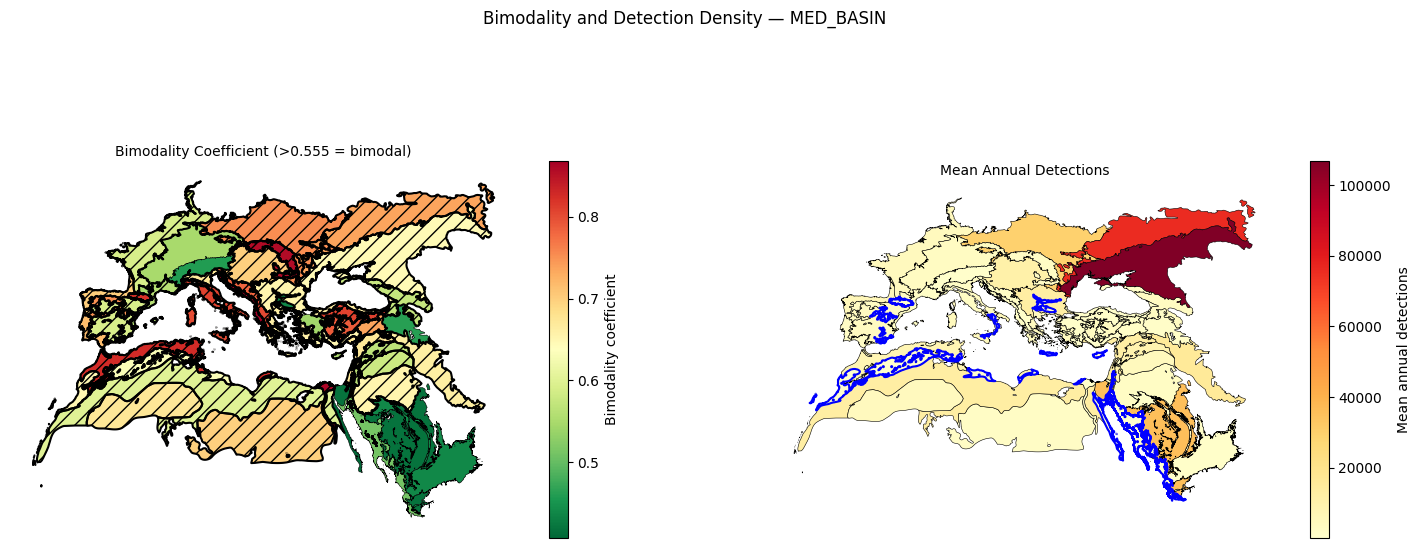

In [22]:
# ── GRAPH 04: Bimodality Coefficient Map ──────────────────────────────────────
with open(f'{OUTPUT_DIR}/eco_geometries.json') as f:
    geo_records = json.load(f)

eco_gdf = gpd.GeoDataFrame(
    [{'eco_name': r['eco_name'], 'geometry': shape(r['geometry'])} for r in geo_records],
    crs='EPSG:4326'
)

map_df = eco_gdf.merge(flags_df[['eco_name', 'bimodality_coeff', 'flag_bimodal',
                                   'mean_annual_det', 'n_flags']], on='eco_name')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Bimodality and Detection Density — {SCALE.upper()}', fontsize=12)

# Panel 1: bimodality coefficient
map_df.plot(column='bimodality_coeff', ax=axes[0], cmap='RdYlGn_r',
            legend=True, edgecolor='black', linewidth=0.4,
            legend_kwds={'label': 'Bimodality coefficient', 'shrink': 0.7})
axes[0].set_title('Bimodality Coefficient (>0.555 = bimodal)', fontsize=10)

# Overlay flag_bimodal ecoregions with hatching
map_df[map_df['flag_bimodal']].plot(ax=axes[0], facecolor='none',
                                     edgecolor='black', linewidth=1.5, hatch='//')
axes[0].set_axis_off()

# Panel 2: mean annual detections
map_df.plot(column='mean_annual_det', ax=axes[1], cmap='YlOrRd',
            legend=True, edgecolor='black', linewidth=0.4,
            legend_kwds={'label': 'Mean annual detections', 'shrink': 0.7})
axes[1].set_title('Mean Annual Detections', fontsize=10)

# Overlay sparse ecoregions
map_df[map_df['mean_annual_det'] < MIN_ECO_DET].plot(
    ax=axes[1], facecolor='none', edgecolor='blue', linewidth=1.5, hatch='..')
axes[1].set_axis_off()

# Legend patches
axes[0].add_patch(mpatches.Patch(facecolor='none', edgecolor='black',
                                  hatch='//', label='Bimodal (BC>0.555)'))
axes[0].legend(handles=[mpatches.Patch(facecolor='none', edgecolor='black',
               hatch='//', label='Bimodal (BC>0.555)')], fontsize=8, loc='lower left')
axes[1].legend(handles=[mpatches.Patch(facecolor='none', edgecolor='blue',
               hatch='..', label=f'Sparse (<{MIN_ECO_DET} det/yr)')],
               fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_04_bimodality_map.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 05: Metric Plausibility Scatter

**Logic:** Mean onset vs mean season length per ecoregion, coloured by flag status.
The dominant r=−0.94 relationship seen in Turkey should hold at larger scales.
Ecoregions that deviate strongly from the main cloud are candidates for inspection.
Flagged ecoregions should cluster away from the main relationship if flags are working.

**What to look for:**
- Main cloud following a tight negative linear relationship
- Flagged ecoregions clustering in the outlier region (early onset + short season, or late onset + long season)
- Bimodal ecoregions sitting off the main relationship
- Any unflagged ecoregions sitting far from the cloud — these are missed quality issues

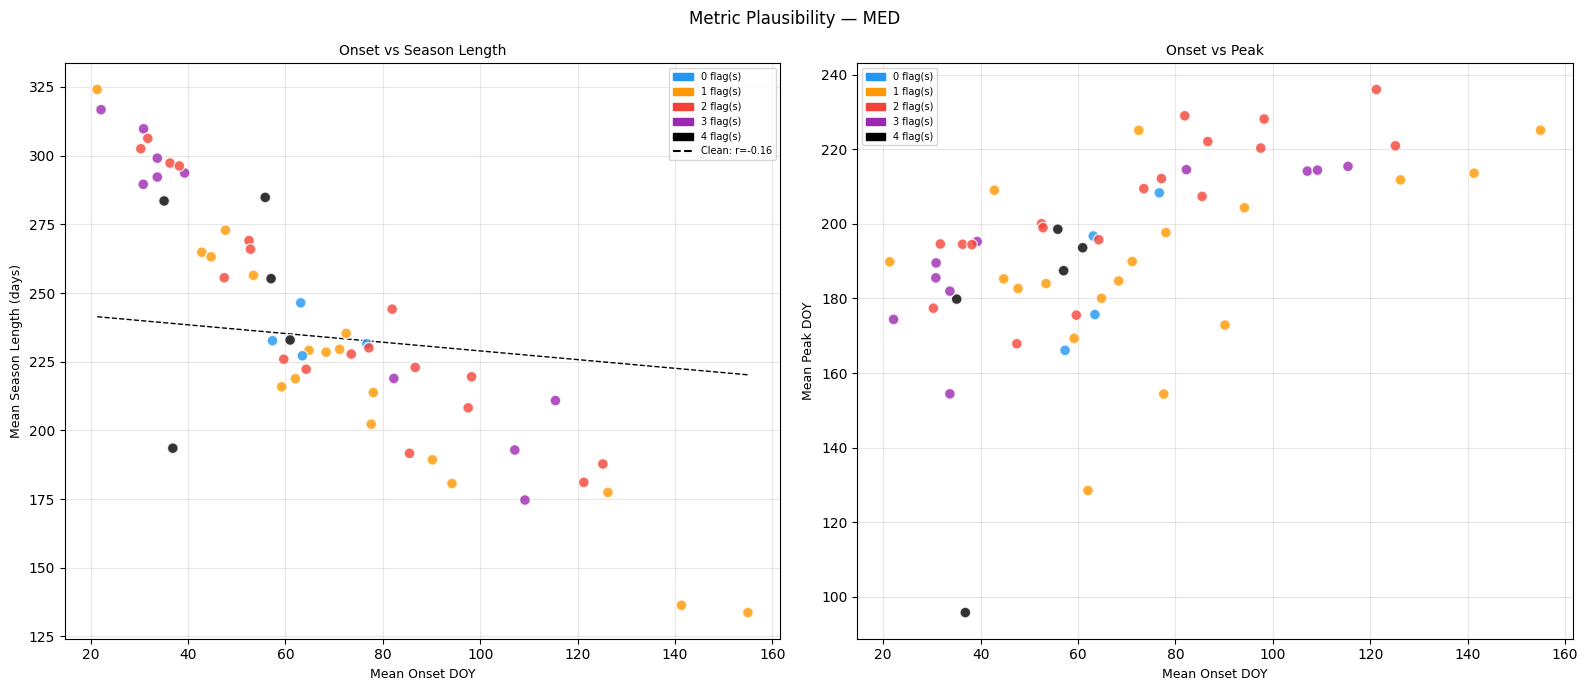

In [12]:
# ── GRAPH 05: Metric Plausibility Scatter ─────────────────────────────────────
mean_metrics = master_df.groupby('eco_name')[[
    'onset_doy', 'peak_doy', 'end_doy', 'season_length'
]].mean().reset_index()

plaus_df = mean_metrics.merge(flags_df[['eco_name', 'n_flags', 'flag_sparse',
                                         'flag_bimodal', 'flag_high_cv']], on='eco_name')

# Colour by number of flags
colors_map = {0: '#2196F3', 1: '#FF9800', 2: '#F44336', 3: '#9C27B0', 4: '#000000'}
point_colors = plaus_df['n_flags'].map(colors_map).fillna('#000000')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Metric Plausibility — {SCALE.upper()}', fontsize=12)

# Panel 1: onset vs season length
ax = axes[0]
ax.scatter(plaus_df['onset_doy'], plaus_df['season_length'],
           c=point_colors, s=60, alpha=0.8, edgecolors='white', zorder=3)

# Trend line
clean = plaus_df[plaus_df['n_flags'] == 0]
if len(clean) > 2:
    slope, intercept, r, p, _ = stats.linregress(clean['onset_doy'], clean['season_length'])
    x_line = np.linspace(plaus_df['onset_doy'].min(), plaus_df['onset_doy'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1,
            linestyle='--', label=f'Clean ecoregions: r={r:.2f}')

ax.set_xlabel('Mean Onset DOY', fontsize=9)
ax.set_ylabel('Mean Season Length (days)', fontsize=9)
ax.set_title('Onset vs Season Length', fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 2: onset vs peak
ax = axes[1]
ax.scatter(plaus_df['onset_doy'], plaus_df['peak_doy'],
           c=point_colors, s=60, alpha=0.8, edgecolors='white', zorder=3)
ax.set_xlabel('Mean Onset DOY', fontsize=9)
ax.set_ylabel('Mean Peak DOY', fontsize=9)
ax.set_title('Onset vs Peak', fontsize=10)
ax.grid(True, alpha=0.3)

# Shared legend
legend_patches = [mpatches.Patch(color=c, label=f'{n} flag(s)')
                  for n, c in colors_map.items() if n <= plaus_df['n_flags'].max()]
axes[0].legend(handles=legend_patches + [plt.Line2D([0],[0], color='black',
               linestyle='--', label=f'Clean: r={r:.2f}')], fontsize=7)
axes[1].legend(handles=legend_patches, fontsize=7)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_05_plausibility_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 06: Annual Detection Heatmap

**Logic:** Total annual detections per ecoregion per year as a heatmap.
Ecoregions sorted by mean annual detections. Shows at a glance which ecoregions
have consistently sparse coverage and which have occasional sparse years.
At Med/global scale this replaces the annotated Turkey heatmap — no numbers,
just colour.

**What to look for:**
- Consistently light rows = sparse ecoregions to flag
- Individual light cells in otherwise dark rows = anomalous low-fire years, not data quality
- Systematic light columns = years with low detection across many ecoregions (sensor issues or genuinely quiet years)

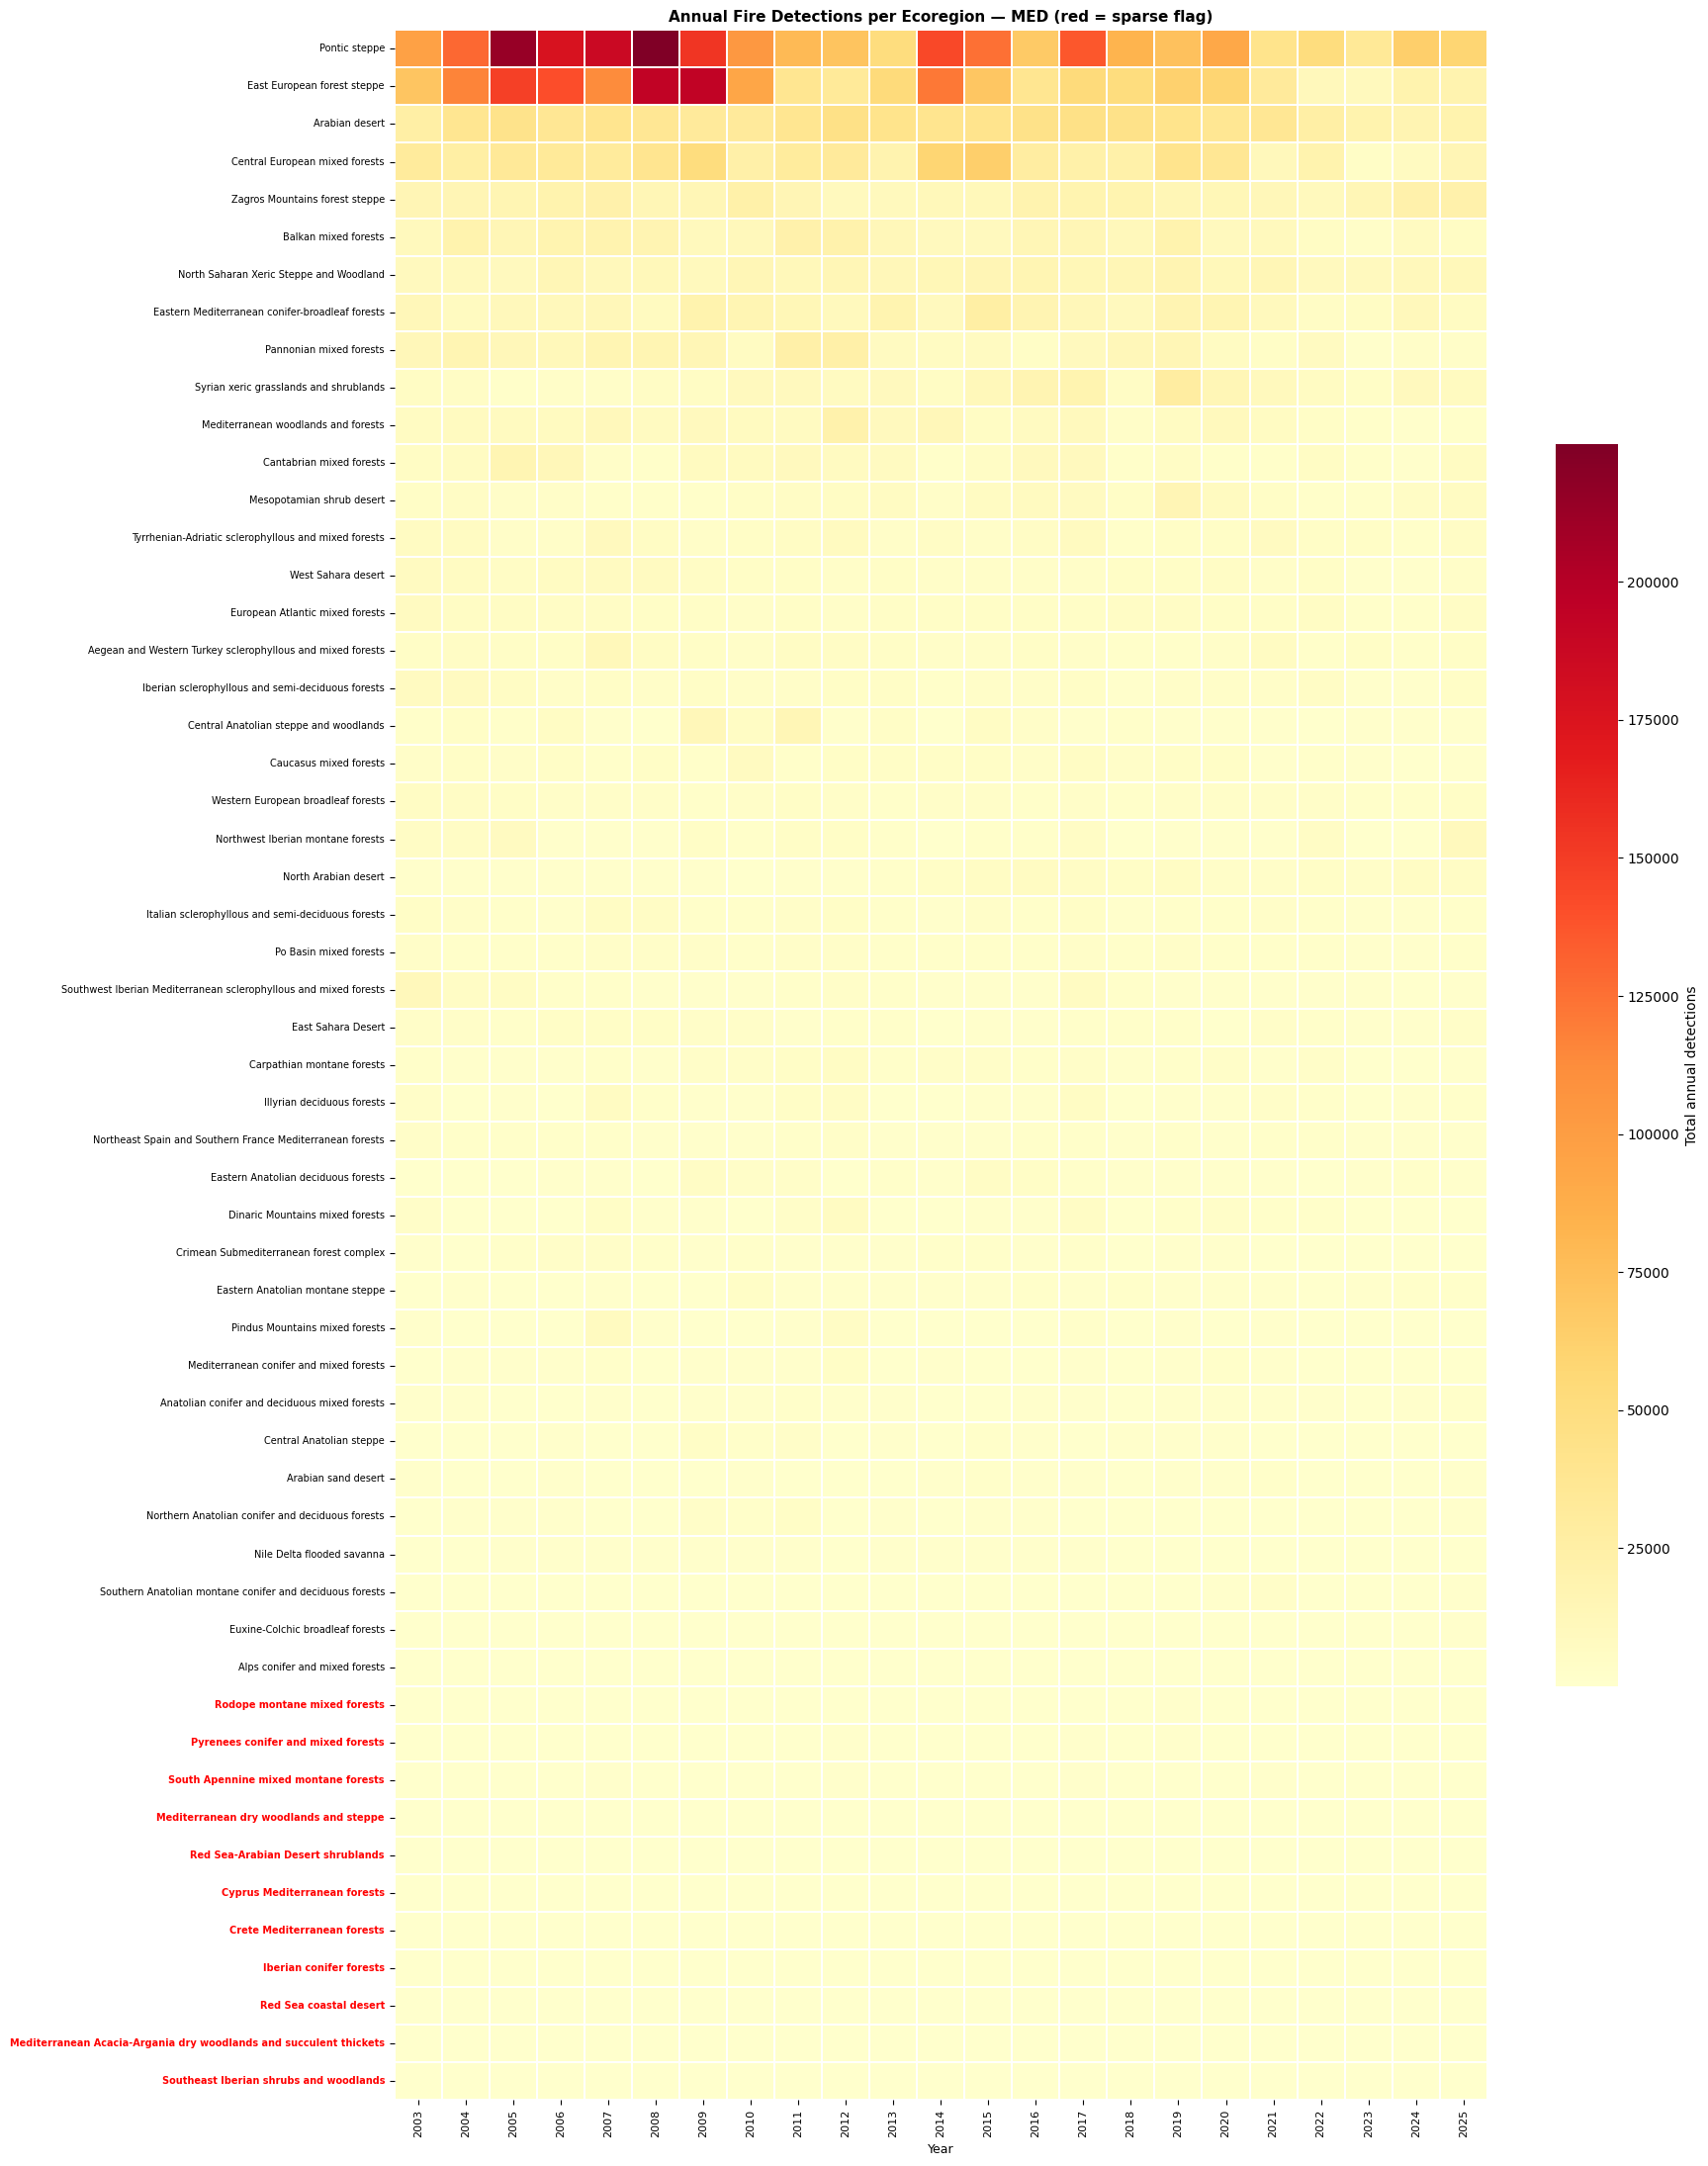

In [13]:
# ── GRAPH 06: Annual Detection Heatmap ───────────────────────────────────────
annual_counts = (
    all_daily.groupby(['eco_name', 'year'])['n_detections']
    .sum()
    .reset_index()
)
pivot_counts = annual_counts.pivot(index='eco_name', columns='year', values='n_detections')

# Sort rows by mean annual detections descending
row_order = pivot_counts.mean(axis=1).sort_values(ascending=False).index
pivot_counts = pivot_counts.loc[row_order]

fig_h = max(8, len(pivot_counts) * 0.4)
fig, ax = plt.subplots(figsize=(18, fig_h))

sns.heatmap(
    pivot_counts,
    ax         = ax,
    cmap       = 'YlOrRd',
    linewidths = 0.3,
    linecolor  = 'white',
    annot      = False,
    cbar_kws   = {'shrink': 0.6, 'label': 'Total annual detections'}
)

# Mark sparse ecoregions on y-axis in red
sparse_ecos = set(flags_df[flags_df['flag_sparse']]['eco_name'])
for label in ax.get_yticklabels():
    if label.get_text() in sparse_ecos:
        label.set_color('red')
        label.set_fontweight('bold')

ax.set_title(f'Annual Fire Detections per Ecoregion — {SCALE.upper()} (red = sparse flag)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)
ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_06_annual_detection_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 07: Anomaly Heatmap

**Logic:** Deviation from each ecoregion's own long-term mean per year.
Removes the between-ecoregion offset so cross-ecoregion comparison of
anomalous years is clean. At larger scales this is far more interpretable
than raw DOY values because ecoregions with very different fire seasons
are put on a common anomaly scale.

**What to look for:**
- Vertical stripes = pan-regional anomaly years (climate-driven signal)
- Horizontal stripes = one ecoregion consistently anomalous (idiosyncratic)
- Random pattern = noise or metric instability
- Whether flagged ecoregions show more random patterns than clean ones

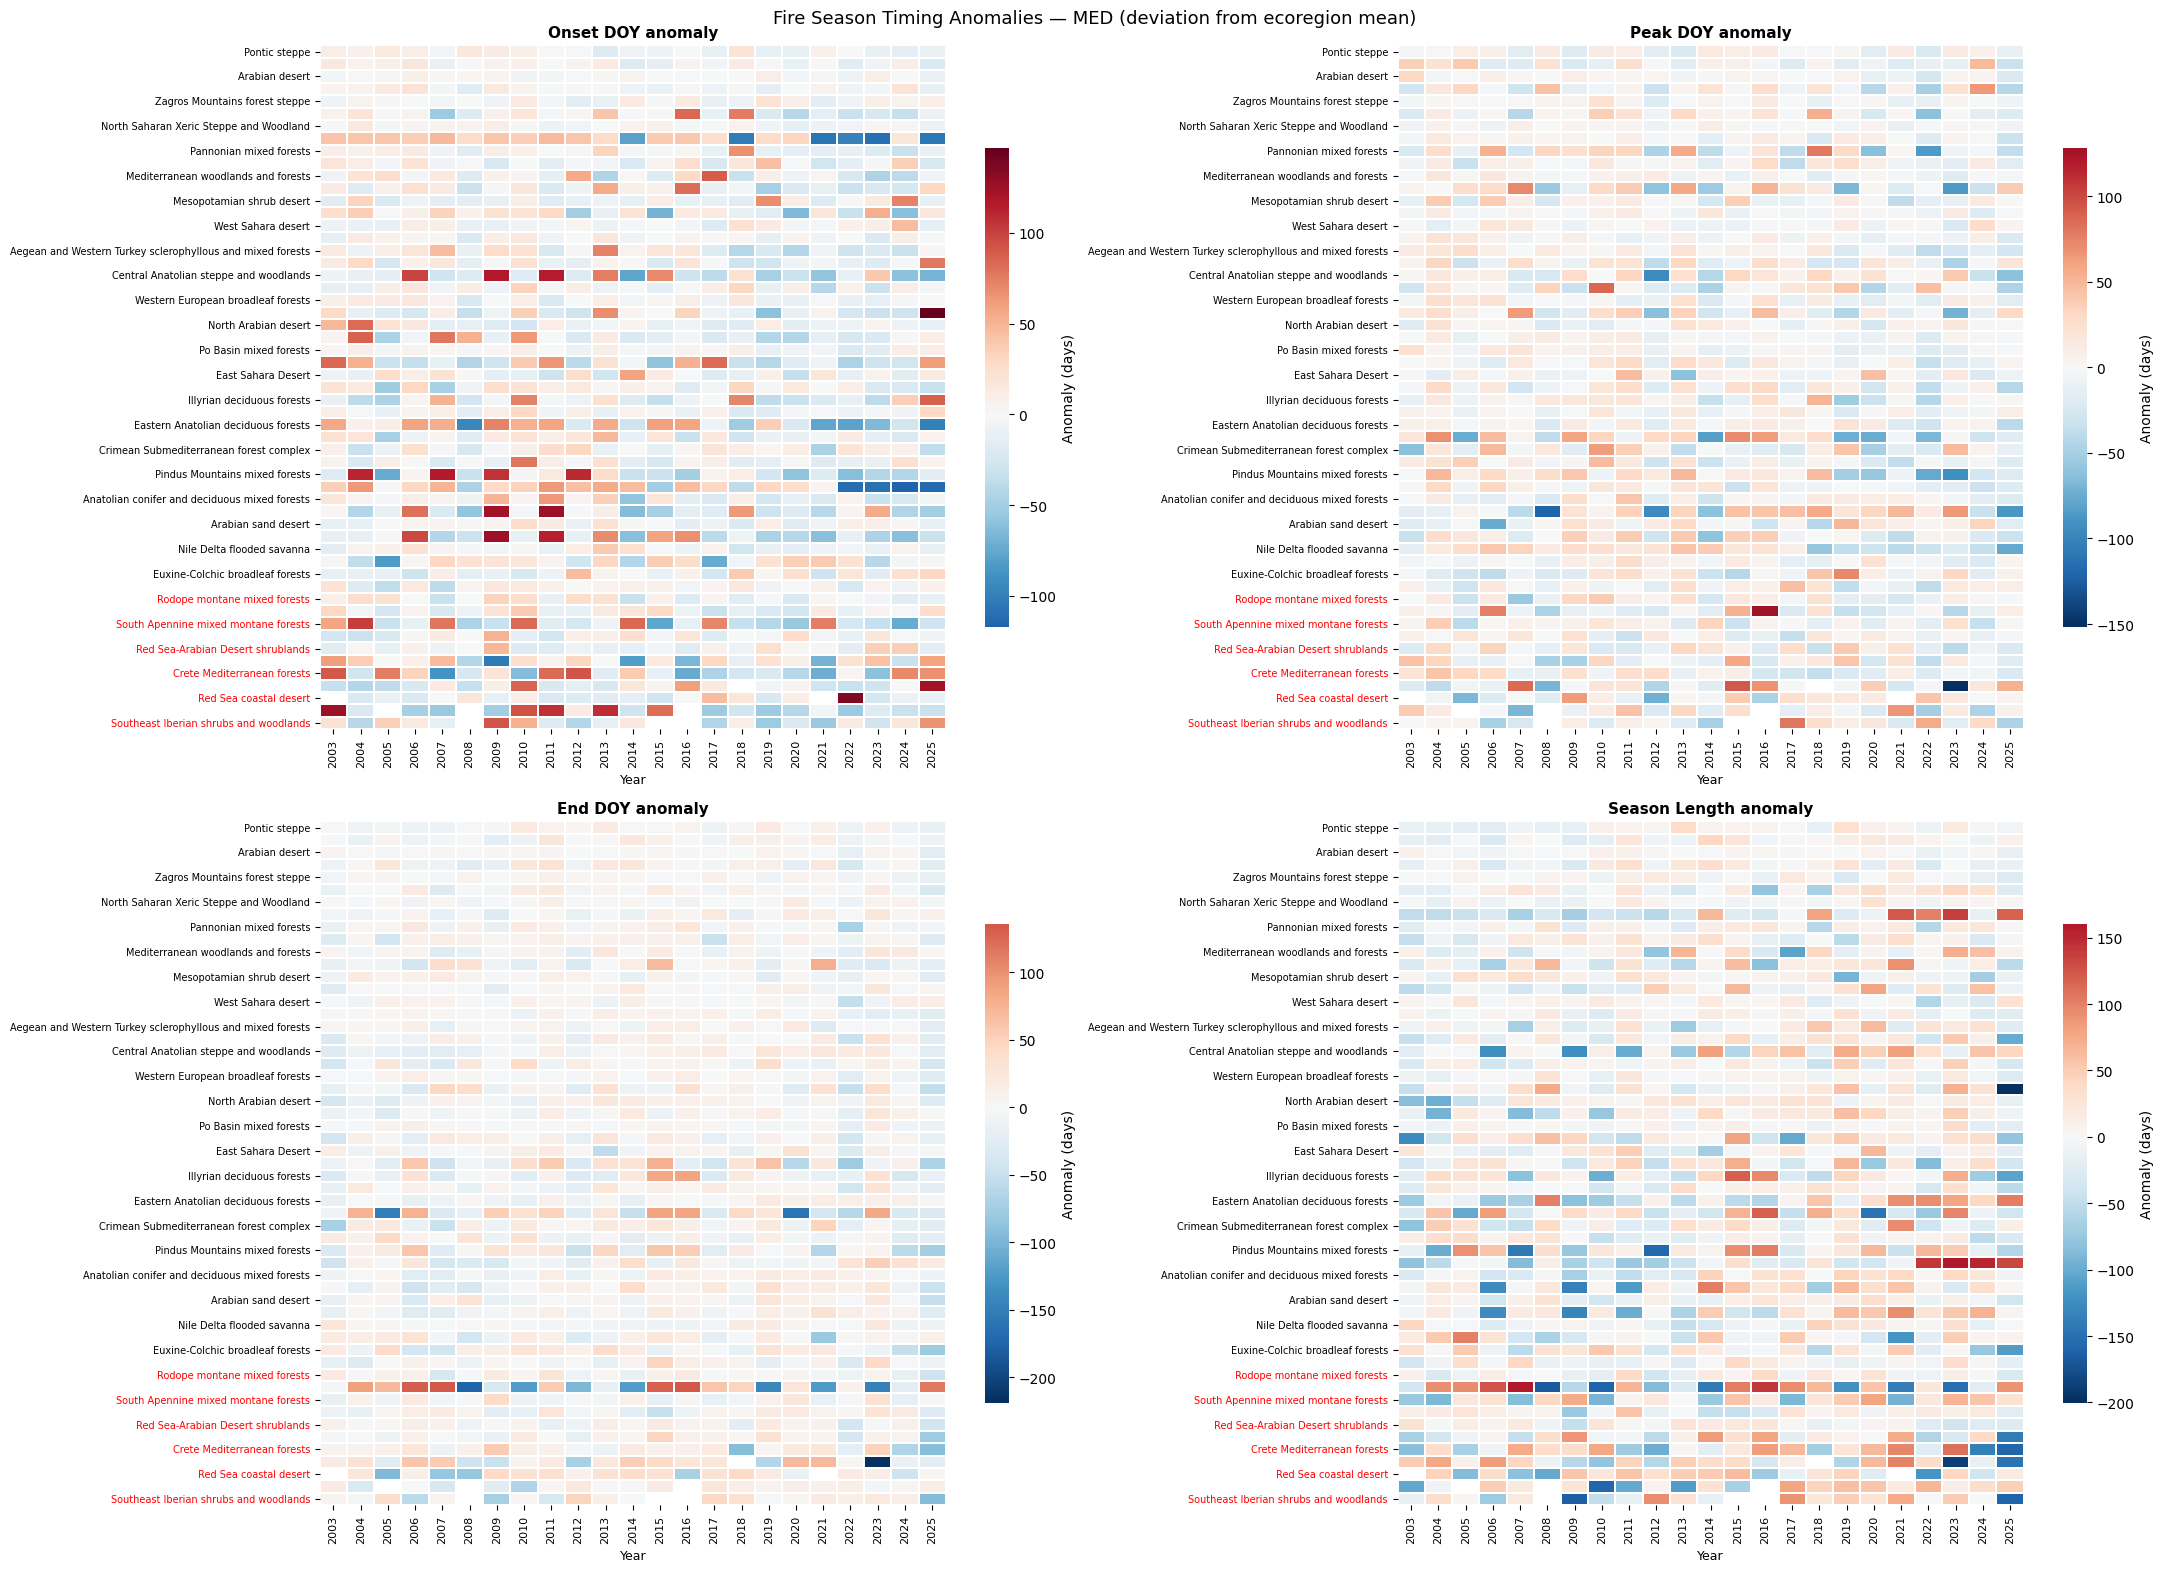

In [14]:
# ── GRAPH 07: Anomaly Heatmap ─────────────────────────────────────────────────
metrics_anom = [
    ('onset_doy',     'Onset DOY anomaly'),
    ('peak_doy',      'Peak DOY anomaly'),
    ('end_doy',       'End DOY anomaly'),
    ('season_length', 'Season Length anomaly'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle(f'Fire Season Timing Anomalies — {SCALE.upper()} (deviation from ecoregion mean)',
             fontsize=13)

for ax, (metric, title) in zip(axes.flatten(), metrics_anom):
    pivot_raw  = master_df.pivot(index='eco_name', columns='year', values=metric)
    pivot_anom = pivot_raw.subtract(pivot_raw.mean(axis=1), axis=0)

    # Sort rows same as detection heatmap for cross-reference
    shared_ecos = [e for e in row_order if e in pivot_anom.index]
    pivot_anom  = pivot_anom.loc[shared_ecos]

    sns.heatmap(
        pivot_anom,
        ax         = ax,
        cmap       = 'RdBu_r',
        center     = 0,
        linewidths = 0.3,
        linecolor  = 'white',
        annot      = False,
        cbar_kws   = {'shrink': 0.7, 'label': 'Anomaly (days)'}
    )

    # Mark sparse ecoregions
    for label in ax.get_yticklabels():
        if label.get_text() in sparse_ecos:
            label.set_color('red')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=8, rotation=90)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_07_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 08: Trends Summary

**Logic:** Instead of a cross-ecoregion mean trend (as in Turkey graph 03),
compute OLS slope per ecoregion and show the *distribution* of slopes across
all ecoregions. This is more informative at scale — it shows whether the trend
signal is consistent across ecoregions or driven by a few outliers.

**What to look for:**
- Distribution centred below zero for onset = most ecoregions trending earlier
- Width of distribution = heterogeneity of trend signal across ecoregions
- Whether flagged ecoregions have more extreme slopes (artefact-driven trends)
- P-value distribution: under the null expect uniform 0–1; if skewed toward 0 the signal is real

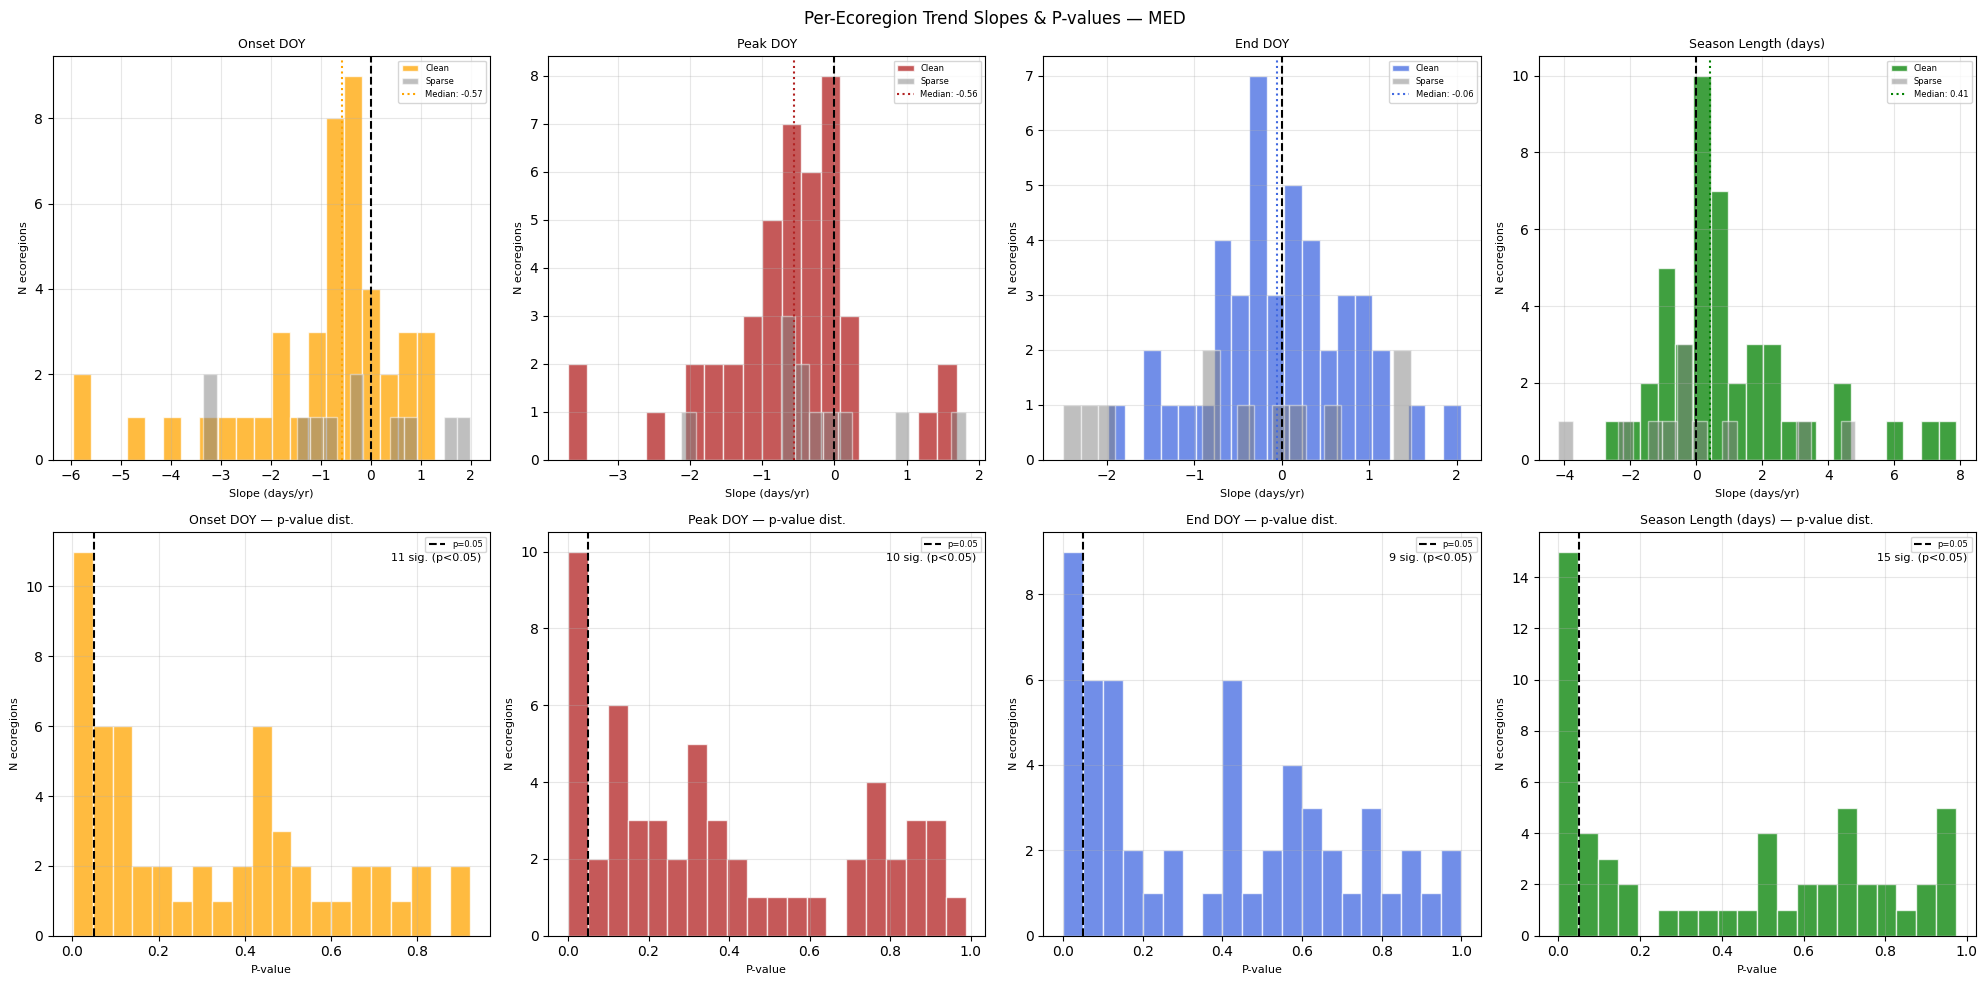

In [15]:
# ── GRAPH 08: Per-Ecoregion Trend Slope Distribution ─────────────────────────
trend_metrics = [
    ('onset_doy',     'Onset DOY',            'orange'),
    ('peak_doy',      'Peak DOY',             'firebrick'),
    ('end_doy',       'End DOY',              'royalblue'),
    ('season_length', 'Season Length (days)', 'green'),
]

# Compute OLS slope per ecoregion per metric
slope_rows = []
for eco in ecoregions:
    sub = master_df[master_df['eco_name'] == eco].sort_values('year')
    if len(sub) < 5:
        continue
    row = {'eco_name': eco}
    for metric, _, _ in trend_metrics:
        sl, _, _, p, _ = stats.linregress(sub['year'], sub[metric])
        row[f'{metric}_slope'] = sl
        row[f'{metric}_pval']  = p
    slope_rows.append(row)

slope_df = pd.DataFrame(slope_rows).merge(
    flags_df[['eco_name', 'n_flags', 'flag_sparse']], on='eco_name'
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'Per-Ecoregion Trend Slopes & P-values — {SCALE.upper()}', fontsize=12)

for col, (metric, label, color) in enumerate(trend_metrics):
    slope_col = f'{metric}_slope'
    pval_col  = f'{metric}_pval'

    # Row 0: slope distribution
    ax = axes[0, col]
    clean_slopes  = slope_df[slope_df['flag_sparse'] == False][slope_col]
    sparse_slopes = slope_df[slope_df['flag_sparse'] == True][slope_col]

    ax.hist(clean_slopes, bins=20, color=color, alpha=0.75,
            edgecolor='white', label='Clean')
    ax.hist(sparse_slopes, bins=20, color='gray', alpha=0.5,
            edgecolor='white', label='Sparse')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.axvline(clean_slopes.median(), color=color, linewidth=1.5,
               linestyle=':', label=f'Median: {clean_slopes.median():.2f}')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Slope (days/yr)', fontsize=8)
    ax.set_ylabel('N ecoregions', fontsize=8)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

    # Row 1: p-value distribution
    ax = axes[1, col]
    ax.hist(slope_df[pval_col], bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0.05, color='black', linewidth=1.5, linestyle='--',
               label='p=0.05')
    n_sig = (slope_df[pval_col] < 0.05).sum()
    ax.text(0.98, 0.95, f'{n_sig} sig. (p<0.05)',
            transform=ax.transAxes, ha='right', va='top', fontsize=8)
    ax.set_xlabel('P-value', fontsize=8)
    ax.set_ylabel('N ecoregions', fontsize=8)
    ax.set_title(f'{label} — p-value dist.', fontsize=9)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_08_trend_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 09: Trend Slope Map

**Logic:** Spatial map of OLS slope per ecoregion for each metric. Shows whether
trends are spatially coherent (expected for climate-driven change) or random
(suggests noise). Significant trends (p<0.05) are hatched.

**What to look for:**
- Spatial clustering of same-sign slopes = coherent regional signal
- Alternating positive/negative slopes with no spatial pattern = noise
- Whether significant trends concentrate in high-detection ecoregions

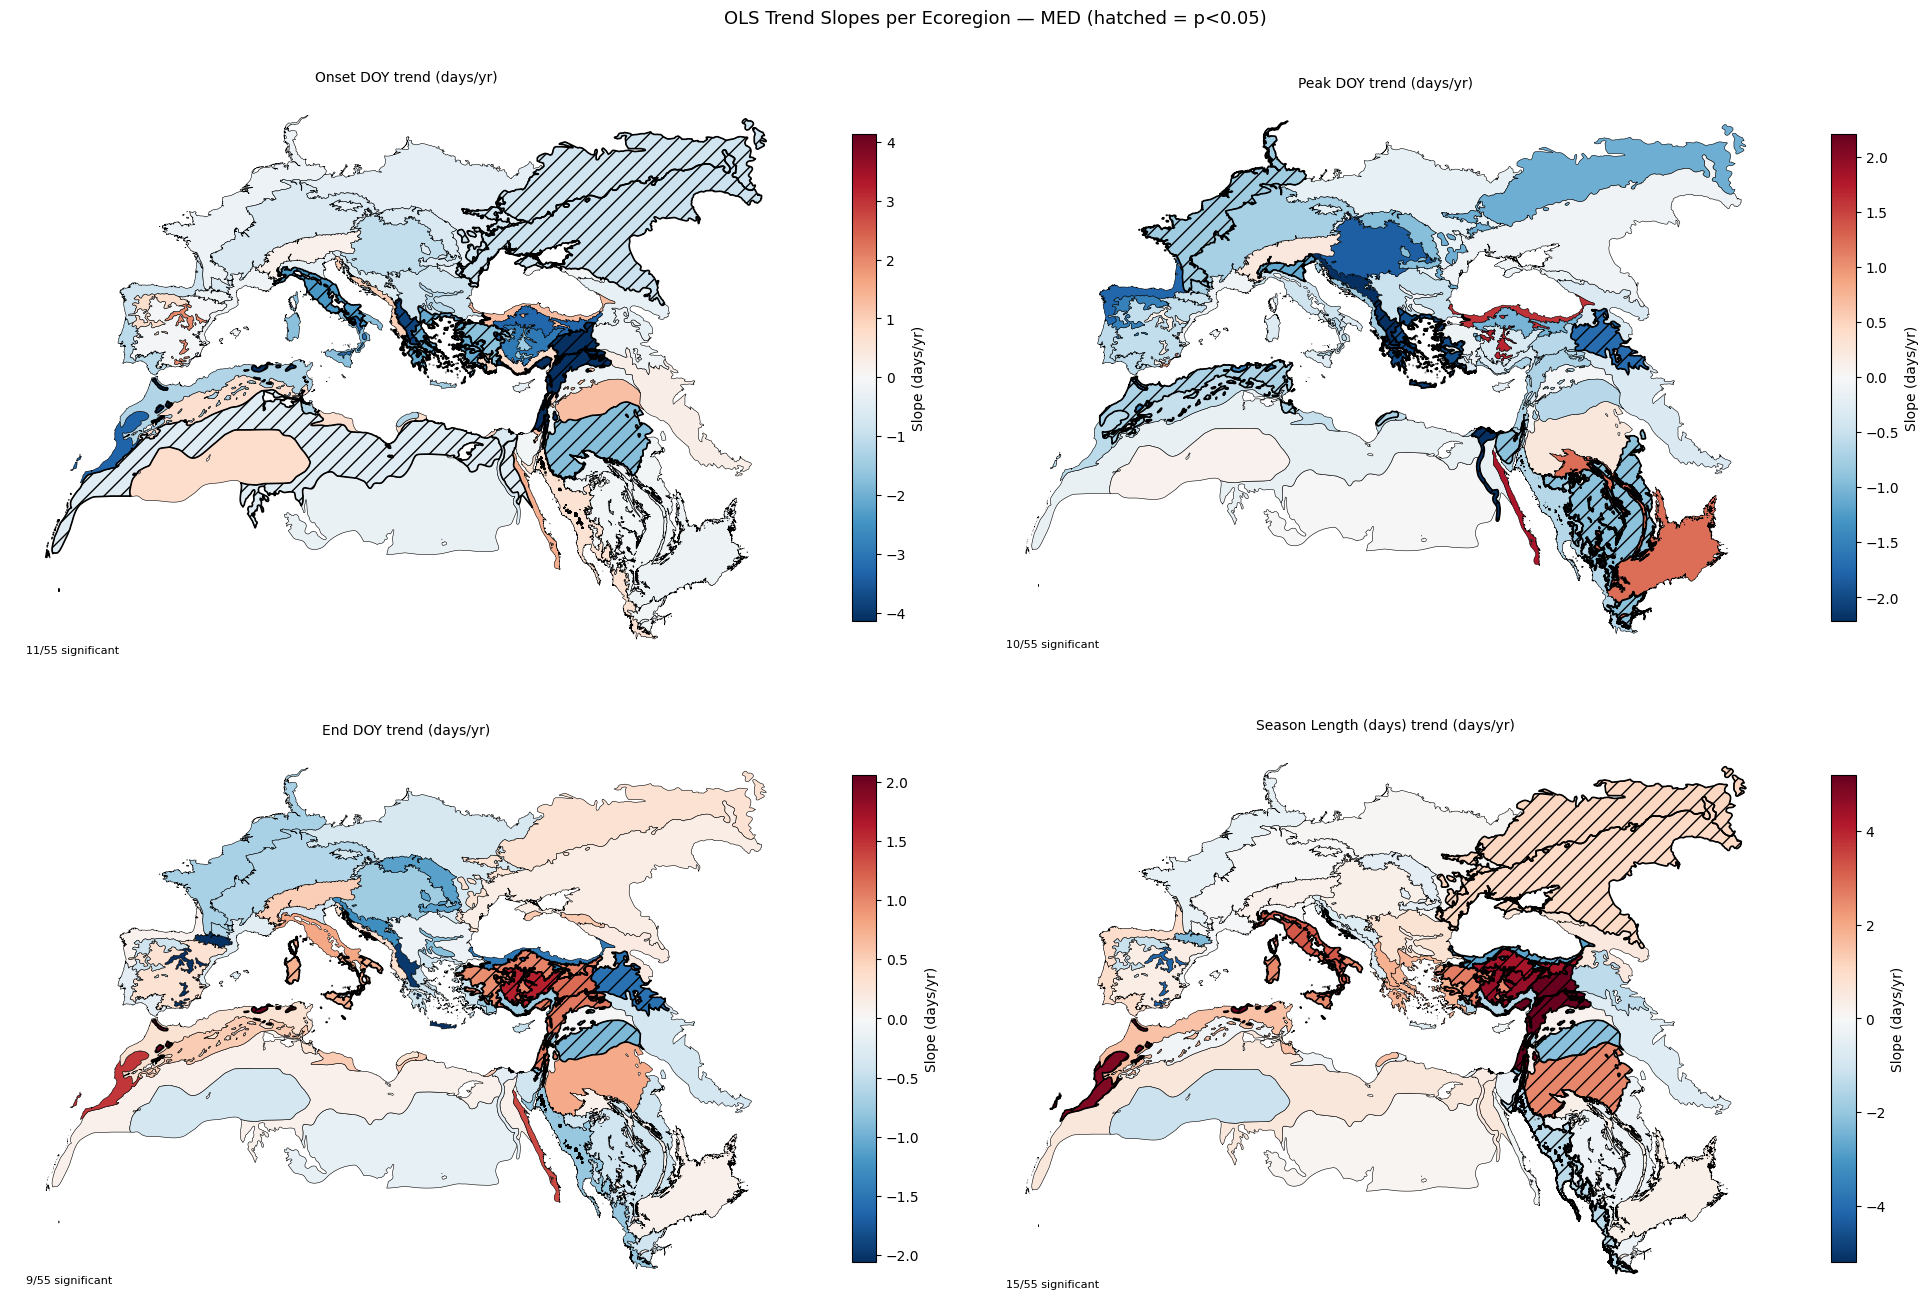

In [16]:
# ── GRAPH 09: Trend Slope Map ─────────────────────────────────────────────────
slope_map_df = eco_gdf.merge(slope_df, on='eco_name')

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(f'OLS Trend Slopes per Ecoregion — {SCALE.upper()} (hatched = p<0.05)',
             fontsize=13)

for ax, (metric, label, _) in zip(axes.flatten(), trend_metrics):
    slope_col = f'{metric}_slope'
    pval_col  = f'{metric}_pval'

    vmax = np.abs(slope_map_df[slope_col]).quantile(0.95)

    slope_map_df.plot(
        column    = slope_col,
        ax        = ax,
        cmap      = 'RdBu_r',
        vmin      = -vmax, vmax = vmax,
        legend    = True,
        edgecolor = 'black',
        linewidth = 0.4,
        legend_kwds = {'label': 'Slope (days/yr)', 'shrink': 0.7}
    )

    # Hatch significant ecoregions
    sig = slope_map_df[slope_map_df[pval_col] < 0.05]
    if len(sig) > 0:
        sig.plot(ax=ax, facecolor='none', edgecolor='black',
                 linewidth=1.2, hatch='//')

    ax.set_title(f'{label} trend (days/yr)', fontsize=10)
    ax.set_axis_off()

    n_sig = (slope_map_df[pval_col] < 0.05).sum()
    ax.text(0.02, 0.02, f'{n_sig}/{len(slope_map_df)} significant',
            transform=ax.transAxes, fontsize=8)

plt.tight_layout()
plt.savefig(f'{graphs_dir}/graph_09_trend_slope_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Targeted Inspection

Fire activity profiles rendered only for ecoregions with 2+ flags.
At Turkey scale (~14 ecoregions) you can look at all profiles.
At Med/global scale you only inspect where flags trigger.

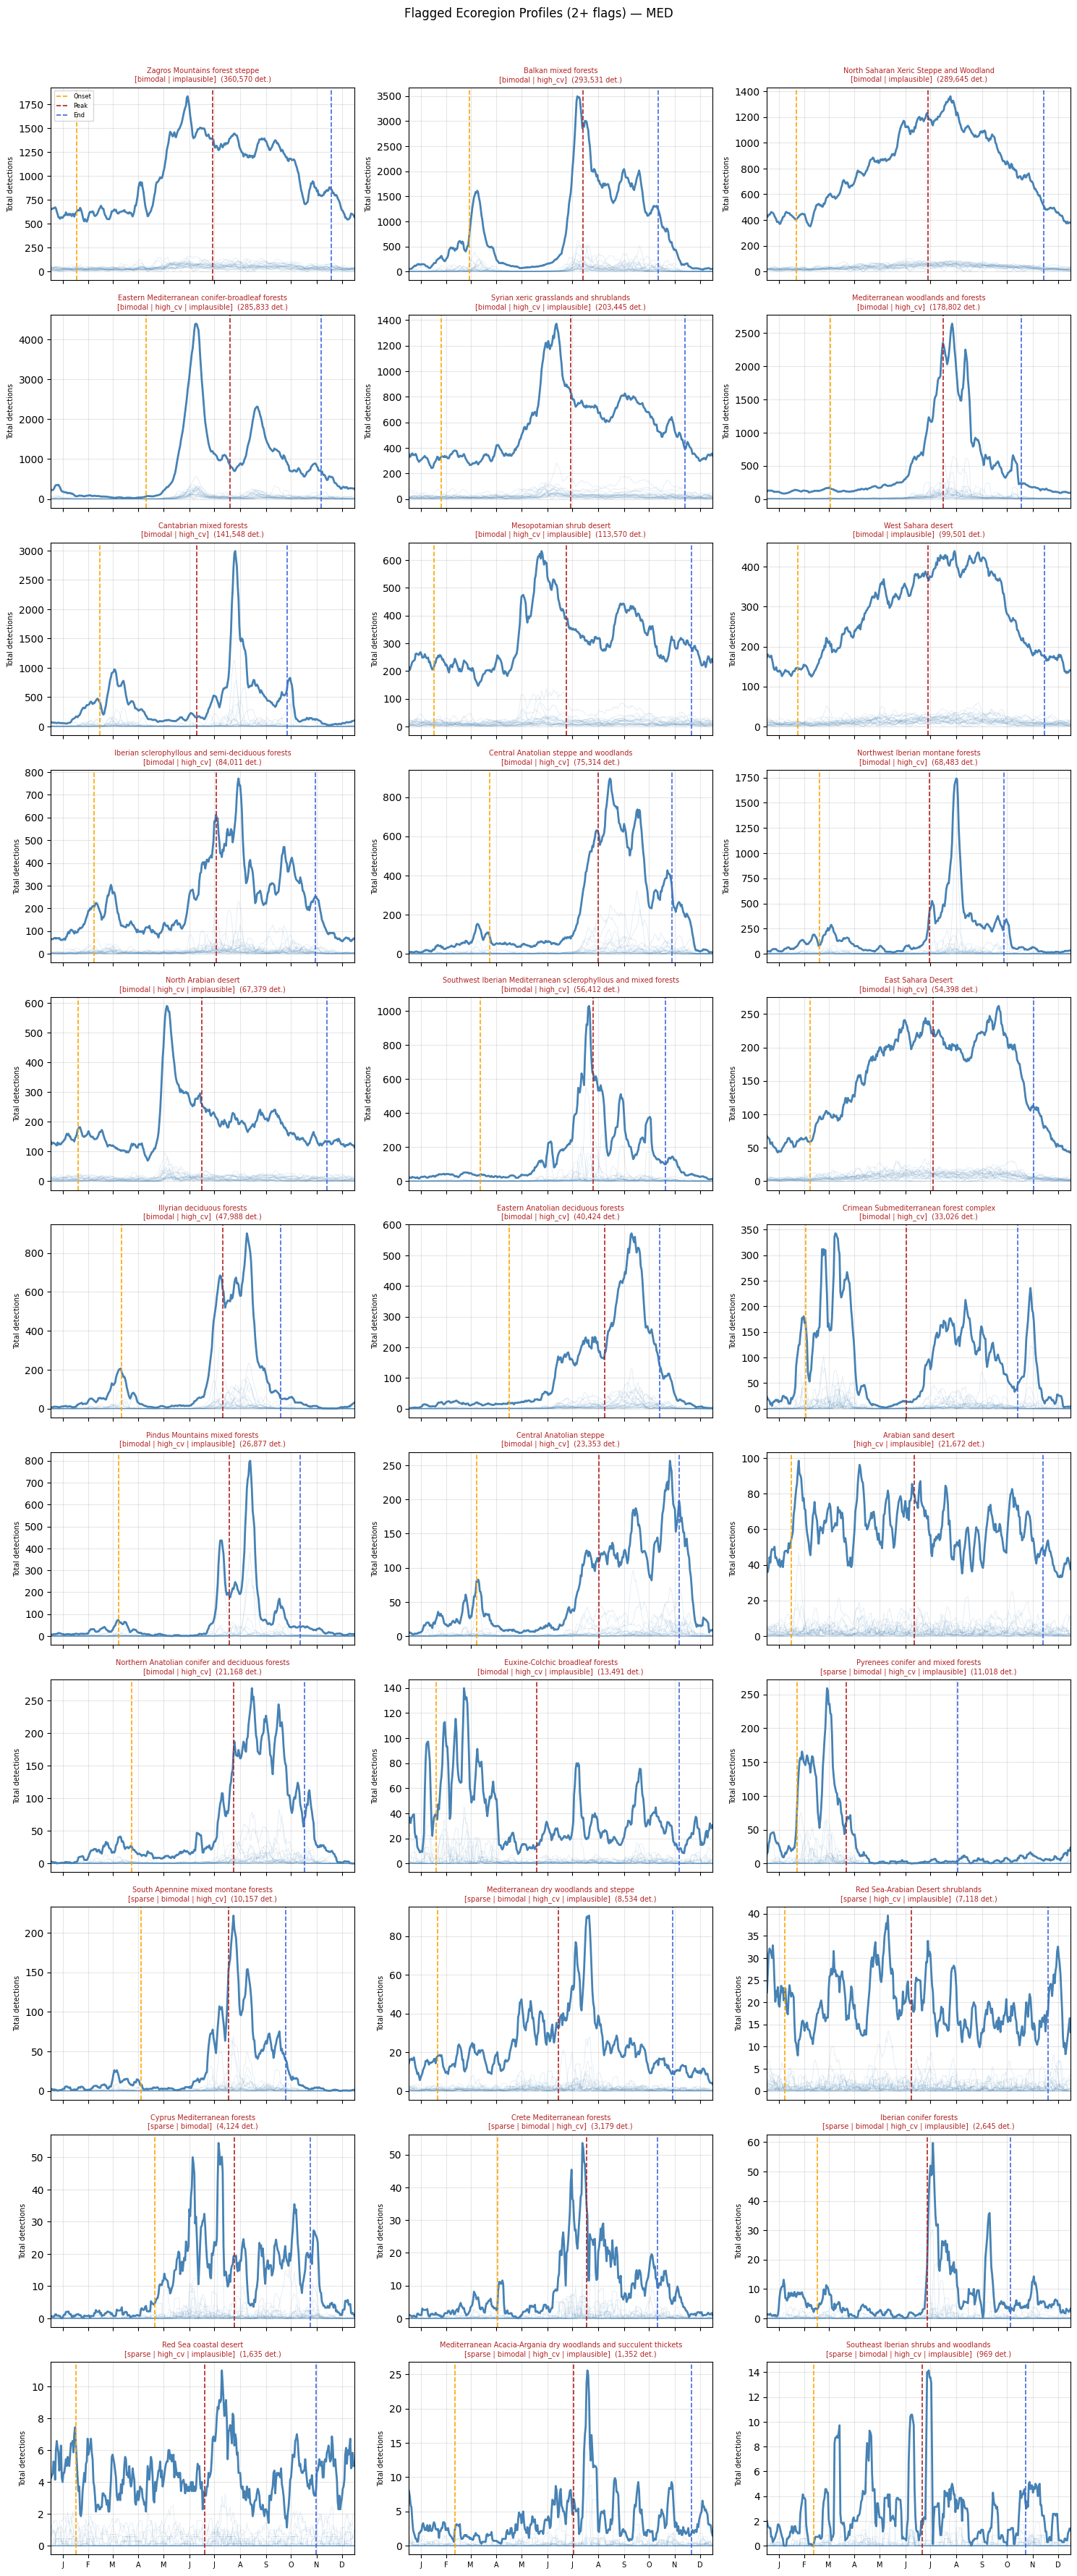

Rendered 33 flagged ecoregions


In [17]:
# ── GRAPH 10: Flagged Ecoregion Profiles ──────────────────────────────────────
# Only renders ecoregions with n_flags >= 2.
# At global scale this keeps the number of panels manageable.

MONTH_TICKS  = [15, 46, 75, 106, 136, 167, 197, 228, 259, 289, 320, 350]
MONTH_LABELS = ['J','F','M','A','M','J','J','A','S','O','N','D']
NCOLS        = 3

flagged_ecos = flags_df[flags_df['n_flags'] >= 2]['eco_name'].tolist()
mean_markers = master_df.groupby('eco_name')[['onset_doy','peak_doy','end_doy']].mean()

if len(flagged_ecos) == 0:
    print('No ecoregions with 2+ flags — no profiles to render.')
else:
    eco_totals = (
        all_daily[all_daily['eco_name'].isin(flagged_ecos)]
        .groupby('eco_name')['n_detections']
        .sum()
        .sort_values(ascending=False)
    )
    flagged_sorted = eco_totals.index.tolist()

    nrows = int(np.ceil(len(flagged_sorted) / NCOLS))
    fig, axes = plt.subplots(nrows, NCOLS,
                              figsize=(NCOLS * 5, nrows * 3.2), sharex=True)
    axes_flat = axes.flatten() if nrows > 1 else [axes] if NCOLS == 1 else axes.flatten()

    for i, eco in enumerate(flagged_sorted):
        ax    = axes_flat[i]
        sub   = all_daily[all_daily['eco_name'] == eco]
        pivot = sub.pivot_table(index='doy', columns='year',
                                values='n_detections', aggfunc='sum')
        pivot = pivot.reindex(range(1, 366)).fillna(0)

        for yr in pivot.columns:
            yr_s = pivot[yr].rolling(SMOOTH_WIN, center=True, min_periods=1).mean()
            ax.plot(pivot.index, yr_s, color='steelblue', alpha=0.15, linewidth=0.6)

        total_smooth = pivot.sum(axis=1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean()
        ax.plot(pivot.index, total_smooth, color='steelblue', linewidth=2)

        if eco in mean_markers.index:
            m = mean_markers.loc[eco]
            ax.axvline(m['onset_doy'], color='orange',    linewidth=1.2,
                       linestyle='--', label='Onset')
            ax.axvline(m['peak_doy'],  color='firebrick',  linewidth=1.2,
                       linestyle='--', label='Peak')
            ax.axvline(m['end_doy'],   color='royalblue',  linewidth=1.2,
                       linestyle='--', label='End')

        # Flag summary in subtitle
        eco_flags = flags_df[flags_df['eco_name'] == eco].iloc[0]
        flag_str  = ' | '.join([
            f for f, v in [
                ('sparse', eco_flags['flag_sparse']),
                ('bimodal', eco_flags['flag_bimodal']),
                ('high_cv', eco_flags['flag_high_cv']),
                ('implausible', eco_flags['flag_implausible'])
            ] if v
        ])

        ax.set_title(f'{eco}\n[{flag_str}]  ({int(eco_totals.get(eco, 0)):,} det.)',
                     fontsize=7, color='firebrick')
        ax.set_xticks(MONTH_TICKS)
        ax.set_xticklabels(MONTH_LABELS, fontsize=7)
        ax.set_xlim(1, 365)
        ax.set_ylabel('Total detections', fontsize=7)
        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend(fontsize=6, loc='upper left')

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f'Flagged Ecoregion Profiles (2+ flags) — {SCALE.upper()}',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{graphs_dir}/graph_10_flagged_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Rendered {len(flagged_sorted)} flagged ecoregions')

---
## Section 4: Summary Report

Print a plain-text summary of the quality assessment.
Copy this into your lab notebook or manuscript methods section.

In [18]:
# ── QUALITY SUMMARY REPORT ────────────────────────────────────────────────────
total     = len(flags_df)
clean     = (flags_df['n_flags'] == 0).sum()
one_flag  = (flags_df['n_flags'] == 1).sum()
multi     = (flags_df['n_flags'] >= 2).sum()

print('=' * 60)
print(f'QUALITY SUMMARY — {SCALE.upper()}')
print('=' * 60)
print(f'Total ecoregions:          {total}')
print(f'Clean (0 flags):           {clean}  ({clean/total*100:.1f}%)')
print(f'Minor concern (1 flag):    {one_flag}  ({one_flag/total*100:.1f}%)')
print(f'Multi-flag (2+ flags):     {multi}  ({multi/total*100:.1f}%)')
print()
print(f'Flag breakdown:')
print(f'  Sparse detection:        {flags_df["flag_sparse"].sum()}')
print(f'  Bimodal profile:         {flags_df["flag_bimodal"].sum()}')
print(f'  High onset CV:           {flags_df["flag_high_cv"].sum()}')
print(f'  Implausible season len:  {flags_df["flag_implausible"].sum()}')
print()
print('Ecoregions with 2+ flags (recommend manual inspection):')
for _, row in flags_df[flags_df['n_flags'] >= 2].sort_values('n_flags', ascending=False).iterrows():
    print(f'  {row["eco_name"]:60s}  n_flags={int(row["n_flags"])}')
print('=' * 60)

QUALITY SUMMARY — MED
Total ecoregions:          55
Clean (0 flags):           4  (7.3%)
Minor concern (1 flag):    18  (32.7%)
Multi-flag (2+ flags):     33  (60.0%)

Flag breakdown:
  Sparse detection:        11
  Bimodal profile:         46
  High onset CV:           29
  Implausible season len:  18

Ecoregions with 2+ flags (recommend manual inspection):
  Mediterranean dry woodlands and steppe                        n_flags=4
  Southeast Iberian shrubs and woodlands                        n_flags=4
  Mediterranean Acacia-Argania dry woodlands and succulent thickets  n_flags=4
  Iberian conifer forests                                       n_flags=4
  Pyrenees conifer and mixed forests                            n_flags=4
  North Arabian desert                                          n_flags=3
  Euxine-Colchic broadleaf forests                              n_flags=3
  Eastern Mediterranean conifer-broadleaf forests               n_flags=3
  Crete Mediterranean forests             